In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot
import datetime
from statsmodels.tsa.arima_model import ARIMA
from sklearn.metrics import mean_squared_error
import pandas.testing as tm

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score
from imblearn.over_sampling import SMOTE

from textblob import TextBlob

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Input, Layer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving upload_DJIA_table.csv to upload_DJIA_table.csv


In [ ]:
df = pd.read_csv("upload_DJIA_table.csv")
df.head(5)


,Date,Open,High,Low,Close,Volume,Adj Close
0,2016-07-01,17924.240234,18002.380859,17916.910156,17949.369141,82160000,17949.369141
1,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234
2,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688
3,2016-06-28,17190.509766,17409.720703,17190.509766,17409.720703,112190000,17409.720703
4,2016-06-27,17355.210938,17355.210938,17063.080078,17140.240234,138740000,17140.240234


In [ ]:
df=df.iloc[::-1]
df

,Date,Open,High,Low,Close,Volume,Adj Close
1988,2008-08-08,11432.089844,11759.959961,11388.040039,11734.320312,212830000,11734.320312
1987,2008-08-11,11729.669922,11867.110352,11675.530273,11782.349609,183190000,11782.349609
1986,2008-08-12,11781.700195,11782.349609,11601.519531,11642.469727,173590000,11642.469727
1985,2008-08-13,11632.809570,11633.780273,11453.339844,11532.959961,182550000,11532.959961
1984,2008-08-14,11532.070312,11718.280273,11450.889648,11615.929688,159790000,11615.929688
...,...,...,...,...,...,...,...
4,2016-06-27,17355.210938,17355.210938,17063.080078,17140.240234,138740000,17140.240234
3,2016-06-28,17190.509766,17409.720703,17190.509766,17409.720703,112190000,17409.720703
2,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688
1,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234


In [ ]:

#The index has been replaced with the dates
df.index=df.Date
df
#df['Date'] = pd.to_datetime(df['Date'])
#df = df.set_index('Date')

,Date,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,,
2008-08-08,2008-08-08,11432.089844,11759.959961,11388.040039,11734.320312,212830000,11734.320312
2008-08-11,2008-08-11,11729.669922,11867.110352,11675.530273,11782.349609,183190000,11782.349609
2008-08-12,2008-08-12,11781.700195,11782.349609,11601.519531,11642.469727,173590000,11642.469727
2008-08-13,2008-08-13,11632.809570,11633.780273,11453.339844,11532.959961,182550000,11532.959961
2008-08-14,2008-08-14,11532.070312,11718.280273,11450.889648,11615.929688,159790000,11615.929688
...,...,...,...,...,...,...,...
2016-06-27,2016-06-27,17355.210938,17355.210938,17063.080078,17140.240234,138740000,17140.240234
2016-06-28,2016-06-28,17190.509766,17409.720703,17190.509766,17409.720703,112190000,17409.720703
2016-06-29,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688


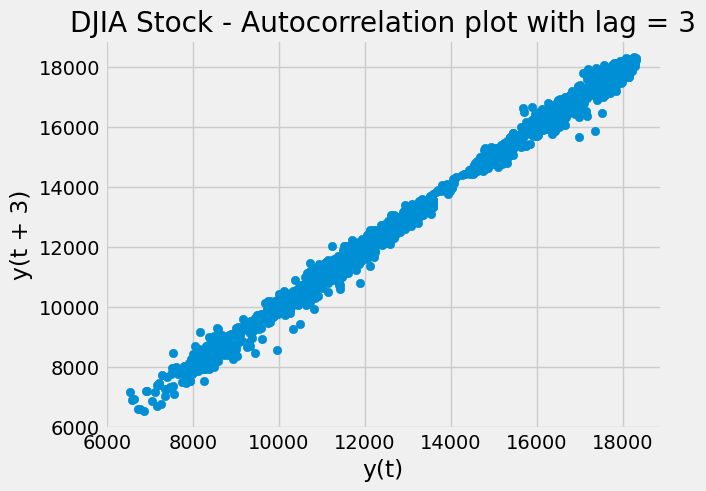

In [ ]:
plt.figure()
lag_plot(df['Open'], lag=3)
plt.title('DJIA Stock - Autocorrelation plot with lag = 3')
plt.show()


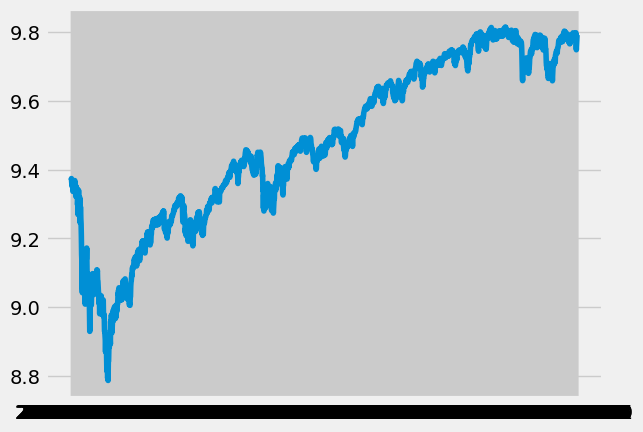

In [ ]:

ts_log = np.log(df["Close"])
plt.plot(ts_log)

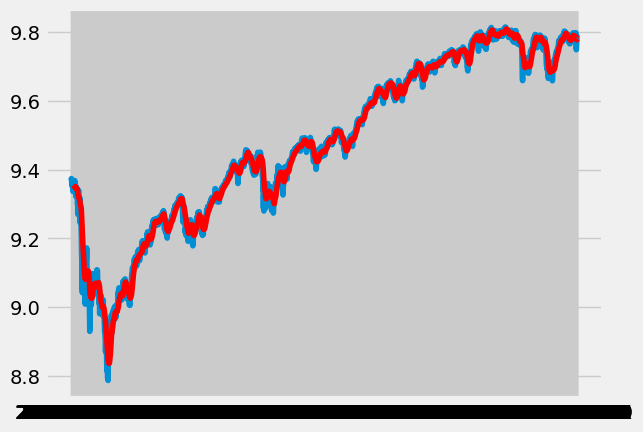

In [ ]:
moving_avg = ts_log.rolling(12).mean()
plt.plot(ts_log)
plt.plot(moving_avg, color='red')


In [ ]:

ts_log_moving_avg_diff = ts_log - moving_avg
ts_log_moving_avg_diff.head(20)

,Close
Date,
2008-08-08,NaN
2008-08-11,NaN
2008-08-12,NaN
2008-08-13,NaN
2008-08-14,NaN
2008-08-15,NaN
2008-08-18,NaN
2008-08-19,NaN
2008-08-20,NaN


In [ ]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):

    #Determing rolling statistics
    rolmean = timeseries.rolling(12).mean()
    rolstd = timeseries.rolling(12).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)


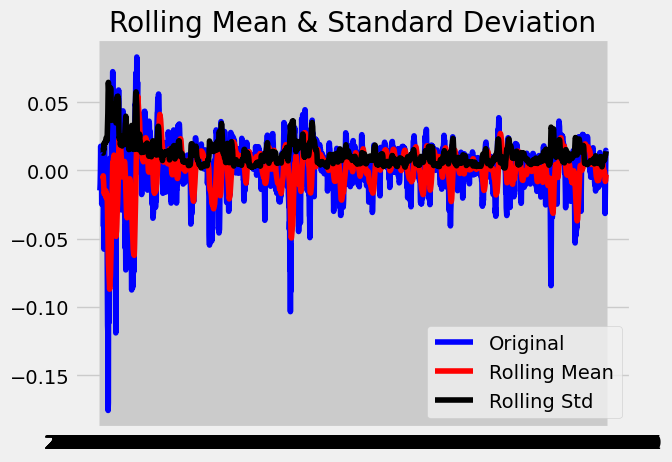

Results of Dickey-Fuller Test:
Test Statistic                -8.004468e+00
p-value                        2.287311e-12
#Lags Used                     2.100000e+01
Number of Observations Used    1.956000e+03
Critical Value (1%)           -3.433698e+00
Critical Value (5%)           -2.863019e+00
Critical Value (10%)          -2.567557e+00
dtype: float64


In [ ]:

ts_log_moving_avg_diff.dropna(inplace=True)
test_stationarity(ts_log_moving_avg_diff)
#WE can say with 92% confidence this is a stationary series

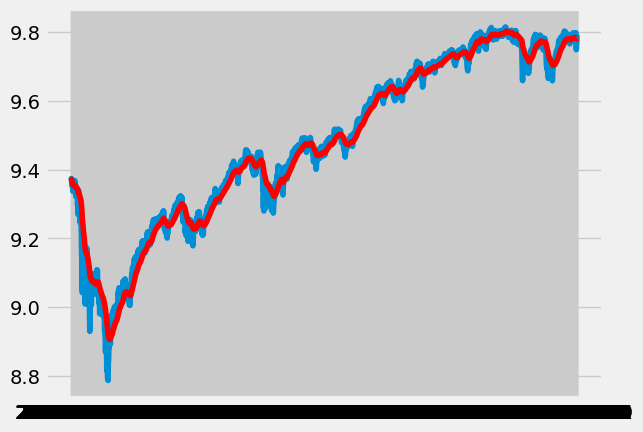

In [ ]:
expwighted_avg = ts_log.ewm(halflife=12).mean()
plt.plot(ts_log)
plt.plot(expwighted_avg, color='red')

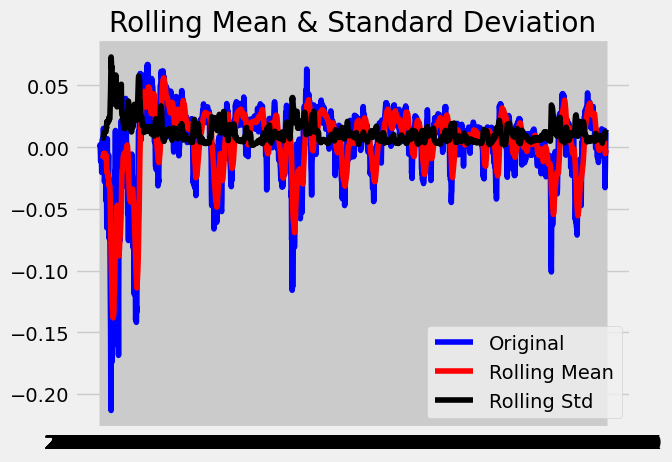

Results of Dickey-Fuller Test:
Test Statistic                -5.674327e+00
p-value                        8.775444e-07
#Lags Used                     2.100000e+01
Number of Observations Used    1.967000e+03
Critical Value (1%)           -3.433679e+00
Critical Value (5%)           -2.863010e+00
Critical Value (10%)          -2.567553e+00
dtype: float64


In [ ]:

ts_log_ewma_diff = ts_log - expwighted_avg
test_stationarity(ts_log_ewma_diff)

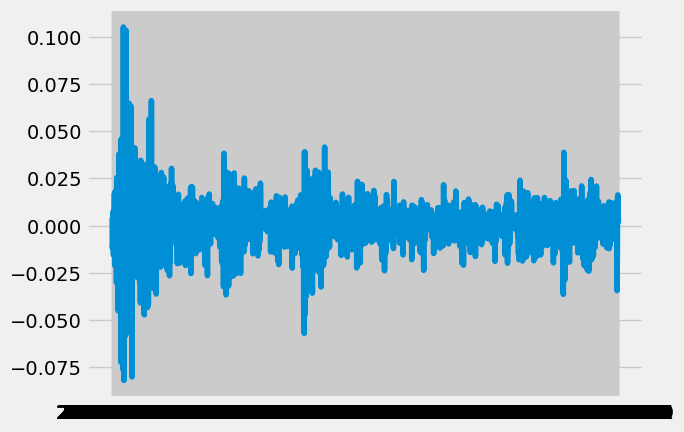

In [ ]:
#Differencing
ts_log_diff = ts_log - ts_log.shift()
plt.plot(ts_log_diff)

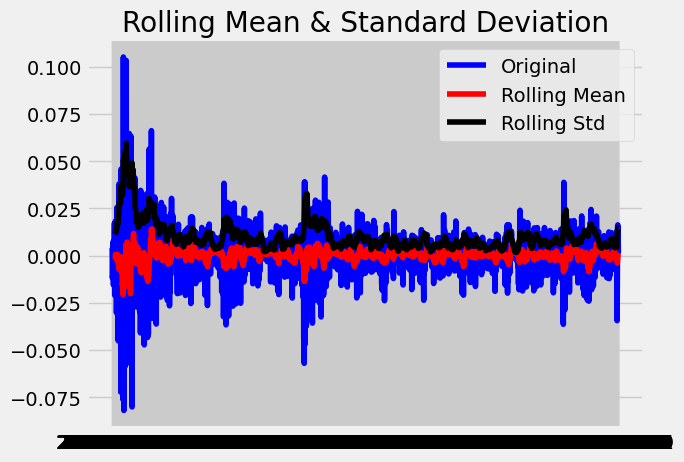

Results of Dickey-Fuller Test:
Test Statistic                -1.040151e+01
p-value                        1.904073e-18
#Lags Used                     2.000000e+01
Number of Observations Used    1.967000e+03
Critical Value (1%)           -3.433679e+00
Critical Value (5%)           -2.863010e+00
Critical Value (10%)          -2.567553e+00
dtype: float64


In [ ]:

ts_log_diff.dropna(inplace=True)
test_stationarity(ts_log_diff)

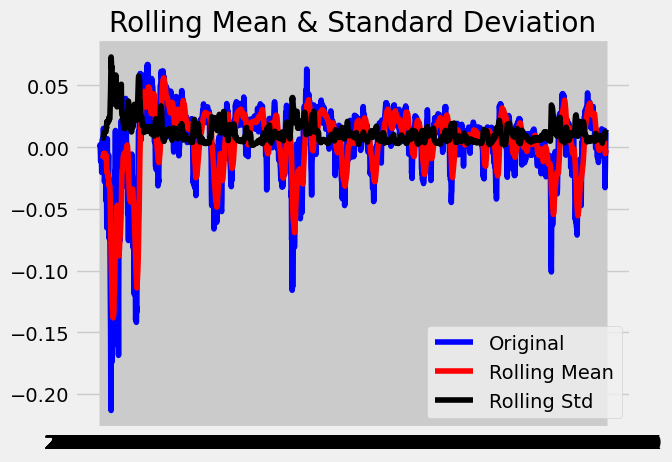

Results of Dickey-Fuller Test:
Test Statistic                -5.674327e+00
p-value                        8.775444e-07
#Lags Used                     2.100000e+01
Number of Observations Used    1.967000e+03
Critical Value (1%)           -3.433679e+00
Critical Value (5%)           -2.863010e+00
Critical Value (10%)          -2.567553e+00
dtype: float64


In [ ]:
ts_log_ewma_diff = ts_log - expwighted_avg
test_stationarity(ts_log_ewma_diff)

In [ ]:
from statsmodels.tsa.stattools import acf, pacf


lag_acf = acf(ts_log_diff, nlags=20)
lag_pacf = pacf(ts_log_diff, nlags=20, method='ols')

Text(0.5, 1.0, 'Autocorrelation Function')

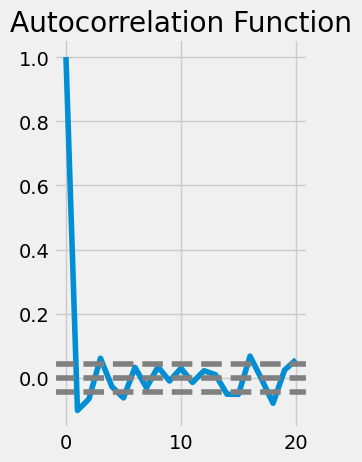

In [ ]:

#Plot ACF:
plt.subplot(121)
plt.plot(lag_acf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.title('Autocorrelation Function')

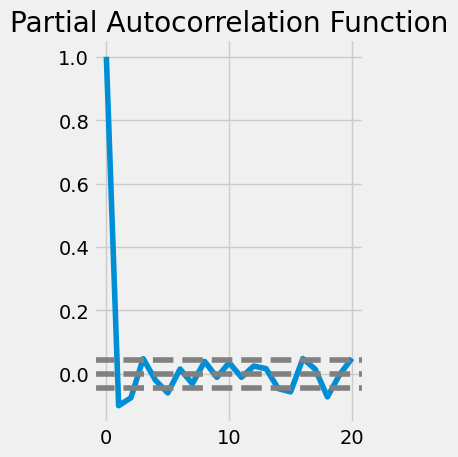

In [ ]:
#Plot PACF:
plt.subplot(122)
plt.plot(lag_pacf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.title('Partial Autocorrelation Function')
plt.tight_layout()

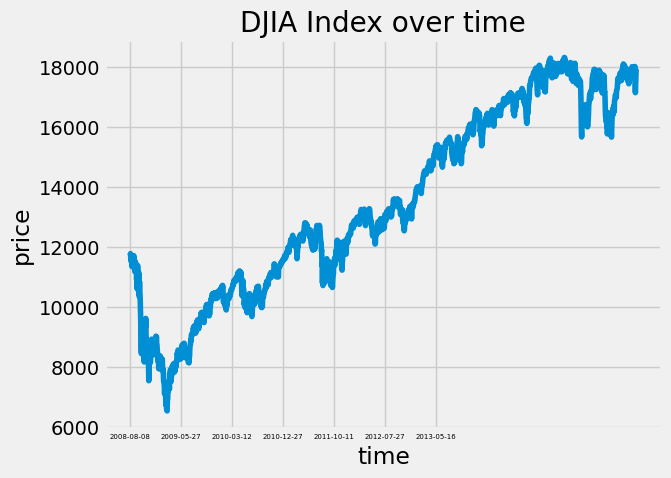

<Figure size 2000x300 with 0 Axes>

In [ ]:

plt.plot( df["Close"]) #df["Date"],
plt.xticks(np.arange(0,1259, 200),df["Date"][0:1259:200])
plt.title("DJIA Index over time")
plt.xlabel("time")
plt.ylabel("price")
plt.tick_params(axis='x', which='major', labelsize=5)
plt.figure(figsize=(20,3))
#plt.tick_params(axis='y', which='major', labelsize=5)
#plt.setp(ax.get_xticklabels(), rotation=30, horizontalalignment='right')#
plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


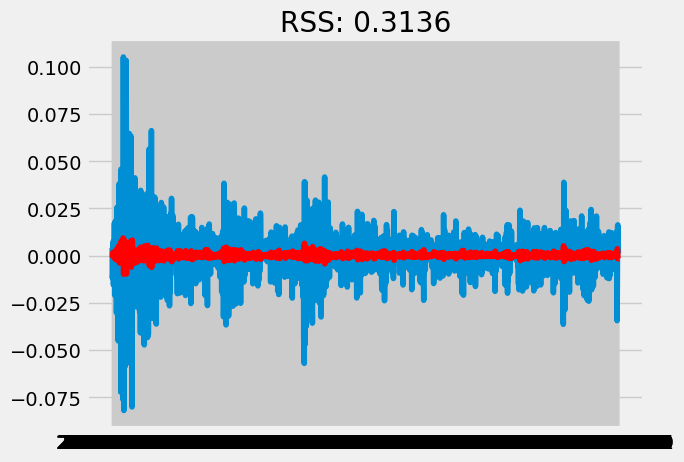

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model2 = ARIMA(ts_log_diff, order=(1, 0, 1))
results_ARIMA = model2.fit()
plt.plot(ts_log_diff)
plt.plot(results_ARIMA.fittedvalues, color='red')
plt.title('RSS: %.4f' % sum((results_ARIMA.fittedvalues - ts_log_diff)**2))
plt.show()

In [ ]:
predictions_ARIMA_diff = pd.Series(results_ARIMA.fittedvalues, copy=True)
print(predictions_ARIMA_diff.head())

Date
2008-08-11    0.000210
2008-08-12   -0.000188
2008-08-13    0.001389
2008-08-14    0.001533
2008-08-15   -0.000185
dtype: float64


In [ ]:

predictions_ARIMA_diff_cumsum = predictions_ARIMA_diff.cumsum()
print(predictions_ARIMA_diff_cumsum.head())

Date
2008-08-11    0.000210
2008-08-12    0.000023
2008-08-13    0.001412
2008-08-14    0.002945
2008-08-15    0.002760
dtype: float64


In [ ]:
predictions_ARIMA_log = pd.Series(ts_log.iloc[0], index=ts_log.index)
predictions_ARIMA_log = predictions_ARIMA_log.add(predictions_ARIMA_diff_cumsum,fill_value=0)
predictions_ARIMA_log.head()

,0
Date,
2008-08-08,9.370273
2008-08-11,9.370483
2008-08-12,9.370296
2008-08-13,9.371685
2008-08-14,9.373218


Text(0.5, 1.0, 'RMSE: 2202.0901')

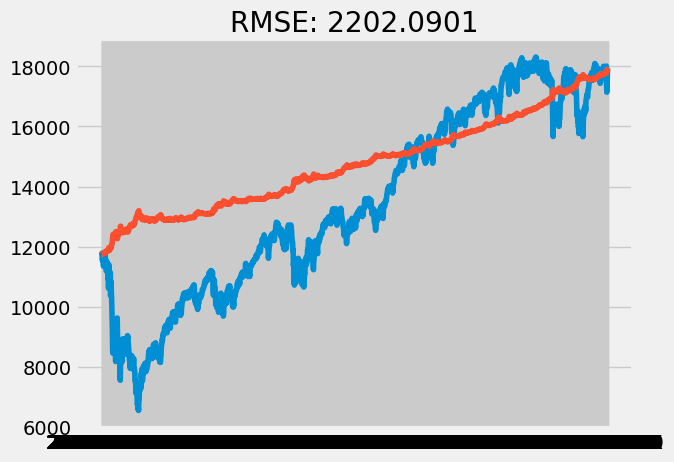

In [ ]:
predictions_ARIMA = np.exp(predictions_ARIMA_log)
plt.plot(df["Close"])
plt.plot(predictions_ARIMA)

#for i in df["close"]
rmse_ARIMA=np.sqrt(sum((predictions_ARIMA-df["Close"])**2)/len(df["Close"]))

plt.title('RMSE: %.4f'% np.sqrt(sum((predictions_ARIMA-df["Close"])**2)/len(df["Close"])))

In [ ]:
predictions_ARIMA_store=predictions_ARIMA[int(len(predictions_ARIMA)*0.75):]


predictions_ARIMA_store

,0
Date,
2014-07-14,15932.298617
2014-07-15,15924.728208
2014-07-16,15925.109179
2014-07-17,15920.426211
2014-07-18,15937.982075
...,...
2016-06-27,17845.958640
2016-06-28,17893.875525
2016-06-29,17879.914215


# **LSTM**

In [ ]:

#LSTM PArt

import math
import pandas_datareader as web
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [ ]:
df = pd.read_csv('upload_DJIA_table.csv')
reversed_df=df.iloc[::-1]
reversed_df

,Date,Open,High,Low,Close,Volume,Adj Close
1988,2008-08-08,11432.089844,11759.959961,11388.040039,11734.320312,212830000,11734.320312
1987,2008-08-11,11729.669922,11867.110352,11675.530273,11782.349609,183190000,11782.349609
1986,2008-08-12,11781.700195,11782.349609,11601.519531,11642.469727,173590000,11642.469727
1985,2008-08-13,11632.809570,11633.780273,11453.339844,11532.959961,182550000,11532.959961
1984,2008-08-14,11532.070312,11718.280273,11450.889648,11615.929688,159790000,11615.929688
...,...,...,...,...,...,...,...
4,2016-06-27,17355.210938,17355.210938,17063.080078,17140.240234,138740000,17140.240234
3,2016-06-28,17190.509766,17409.720703,17190.509766,17409.720703,112190000,17409.720703
2,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688
1,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234


In [ ]:
#The index has been replaced with the dates
reversed_df.index=reversed_df.Date
reversed_df

,Date,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,,
2008-08-08,2008-08-08,11432.089844,11759.959961,11388.040039,11734.320312,212830000,11734.320312
2008-08-11,2008-08-11,11729.669922,11867.110352,11675.530273,11782.349609,183190000,11782.349609
2008-08-12,2008-08-12,11781.700195,11782.349609,11601.519531,11642.469727,173590000,11642.469727
2008-08-13,2008-08-13,11632.809570,11633.780273,11453.339844,11532.959961,182550000,11532.959961
2008-08-14,2008-08-14,11532.070312,11718.280273,11450.889648,11615.929688,159790000,11615.929688
...,...,...,...,...,...,...,...
2016-06-27,2016-06-27,17355.210938,17355.210938,17063.080078,17140.240234,138740000,17140.240234
2016-06-28,2016-06-28,17190.509766,17409.720703,17190.509766,17409.720703,112190000,17409.720703
2016-06-29,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688


In [ ]:

reversed_df.shape

(1989, 7)

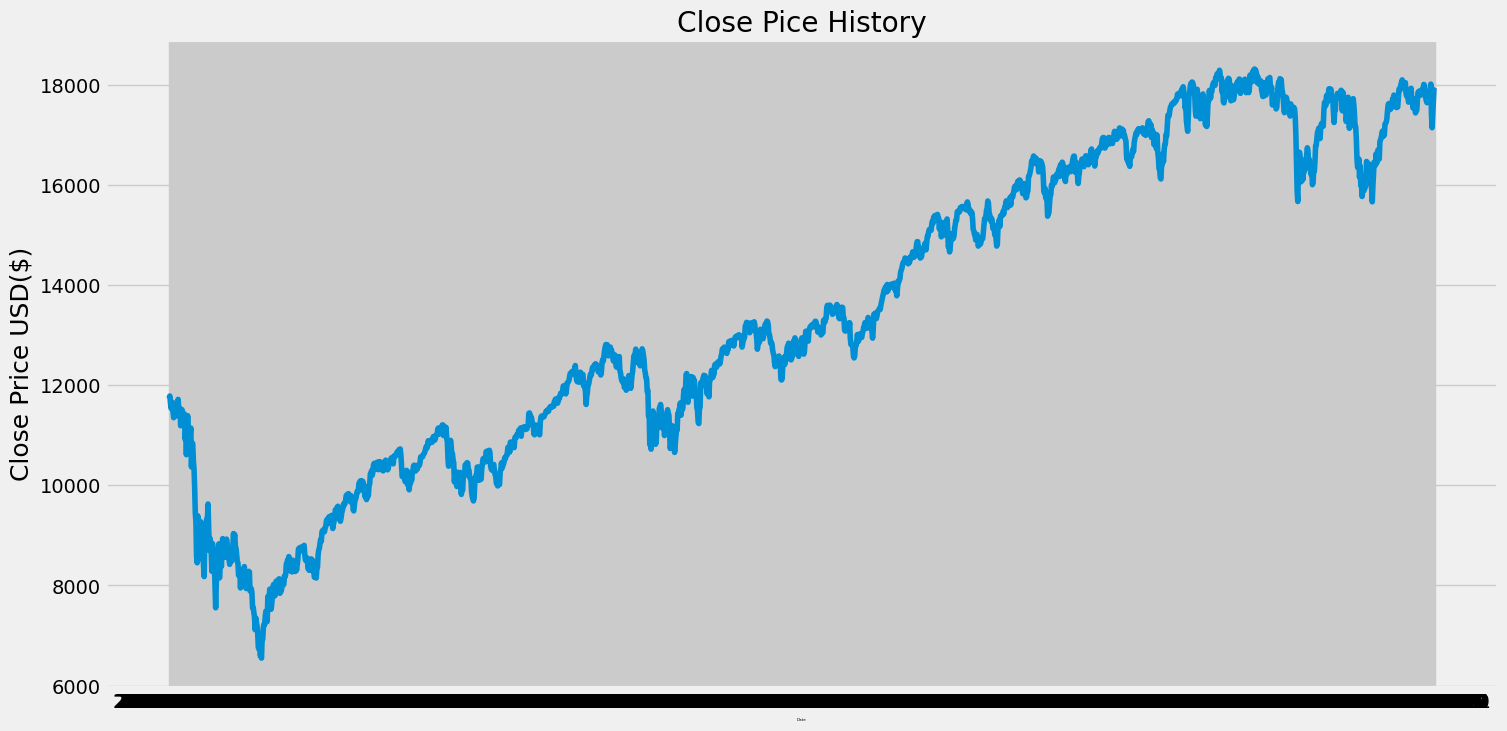

In [ ]:

plt.figure(figsize=(16,8))
plt.title('Close Pice History')
plt.plot(reversed_df['Date'],reversed_df['Close'])
plt.xlabel('Date',fontsize=3)
plt.ylabel('Close Price USD($)',fontsize=18)
plt.show()

In [ ]:
data=reversed_df.filter(['Close'])
dataset=data.values
training_data_len=math.ceil(len(dataset)*.75)

training_data_len


1492

In [ ]:
#Scale the data
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(dataset)

scaled_data

array([[0.4408942 ],
       [0.44497647],
       [0.43308732],
       ...,
       [0.9474974 ],
       [0.96749772],
       [0.96914484]])

In [ ]:
train_data=scaled_data[0:training_data_len,:]
x_train=[]
y_train=[]
for i in range(60,len(train_data)):
  x_train.append(train_data[i-60:i,0])
  y_train.append(train_data[i,0])
  if i<=61:
    print(x_train)
    print(y_train)
    print()


[array([0.4408942 , 0.44497647, 0.43308732, 0.42377949, 0.43083154,
       0.43456885, 0.41922626, 0.40810547, 0.41395995, 0.41504621,
       0.43186252, 0.41130982, 0.41357241, 0.42119137, 0.43926733,
       0.42471444, 0.42241616, 0.42377269, 0.39447907, 0.39726092,
       0.42189092, 0.39809137, 0.4013373 , 0.4153437 , 0.41434757,
       0.37146905, 0.38349673, 0.34530324, 0.38015394, 0.41149599,
       0.37981395, 0.36608545, 0.36362059, 0.3803553 , 0.39064572,
       0.32454652, 0.36578714, 0.36412209, 0.33452493, 0.32114072,
       0.28970263, 0.24649184, 0.2304268 , 0.17272263, 0.16184322,
       0.24143462, 0.23492226, 0.17261381, 0.20672669, 0.19592887,
       0.23104982, 0.21135047, 0.16762457, 0.18224718, 0.15570313,
       0.13843375, 0.21402443, 0.20772115, 0.22384737, 0.23611385])]
[np.float64(0.23567360397129578)]

[array([0.4408942 , 0.44497647, 0.43308732, 0.42377949, 0.43083154,
       0.43456885, 0.41922626, 0.40810547, 0.41395995, 0.41504621,
       0.43186252, 0.41

In [ ]:

x_train, y_train= np.array(x_train), np.array(y_train)
x_train=np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))
x_train.shape


(1432, 60, 1)

In [ ]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(LSTM(50,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train,y_train,batch_size=1,epochs=100)

Epoch 1/100
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 50s 31ms/step - loss: 0.0084
Epoch 2/100
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 88s 36ms/step - loss: 7.1904e-04
Epoch 3/100
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 83s 37ms/step - loss: 5.9264e-04
Epoch 4/100
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 48s 33ms/step - loss: 4.2606e-04
Epoch 5/100
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 85s 36ms/step - loss: 3.8191e-04
Epoch 6/100
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 78s 33ms/step - loss: 3.8686e-04
Epoch 7/100
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - loss: 3.7075e-04
Epoch 8/100
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 60s 42ms/step - loss: 2.7713e-04
Epoch 9/100
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 73s 35ms/step - loss: 2.7442e-04
Epoch 10/100
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 74s 30ms/step - loss: 2.5144e-04
Epoch 11/100
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - loss: 2.2208e-04
Epoch 12/100
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 79s 30ms/step - loss: 2.1851e-04
Epoch 13/100
1432/1432 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - loss: 2.0754e-04
Epoch 14/100

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,705 (373.85 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,804 (249.24 KB)

In [ ]:

model.save("my_lstm_model.keras")


In [ ]:
#from google.colab import files
#files.download("my_lstm_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving my_lstm_model.keras to my_lstm_model.keras


In [ ]:
from tensorflow import keras
model = keras.models.load_model("my_lstm_model.keras")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,705 (373.85 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,804 (249.24 KB)

In [ ]:

test_data=scaled_data[training_data_len - 60: , :]
x_test=[]
y_test=dataset[training_data_len:, :]
for i in range(60,len(test_data)):
  x_test.append(test_data[i - 60:i, 0])

In [ ]:
x_test=np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step


In [ ]:
rmse_LSTM=np.sqrt(np.mean(predictions-y_test)**2)
rmse_LSTM

np.float64(166.6067027214537)

/tmp/ipython-input-387-1892490417.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


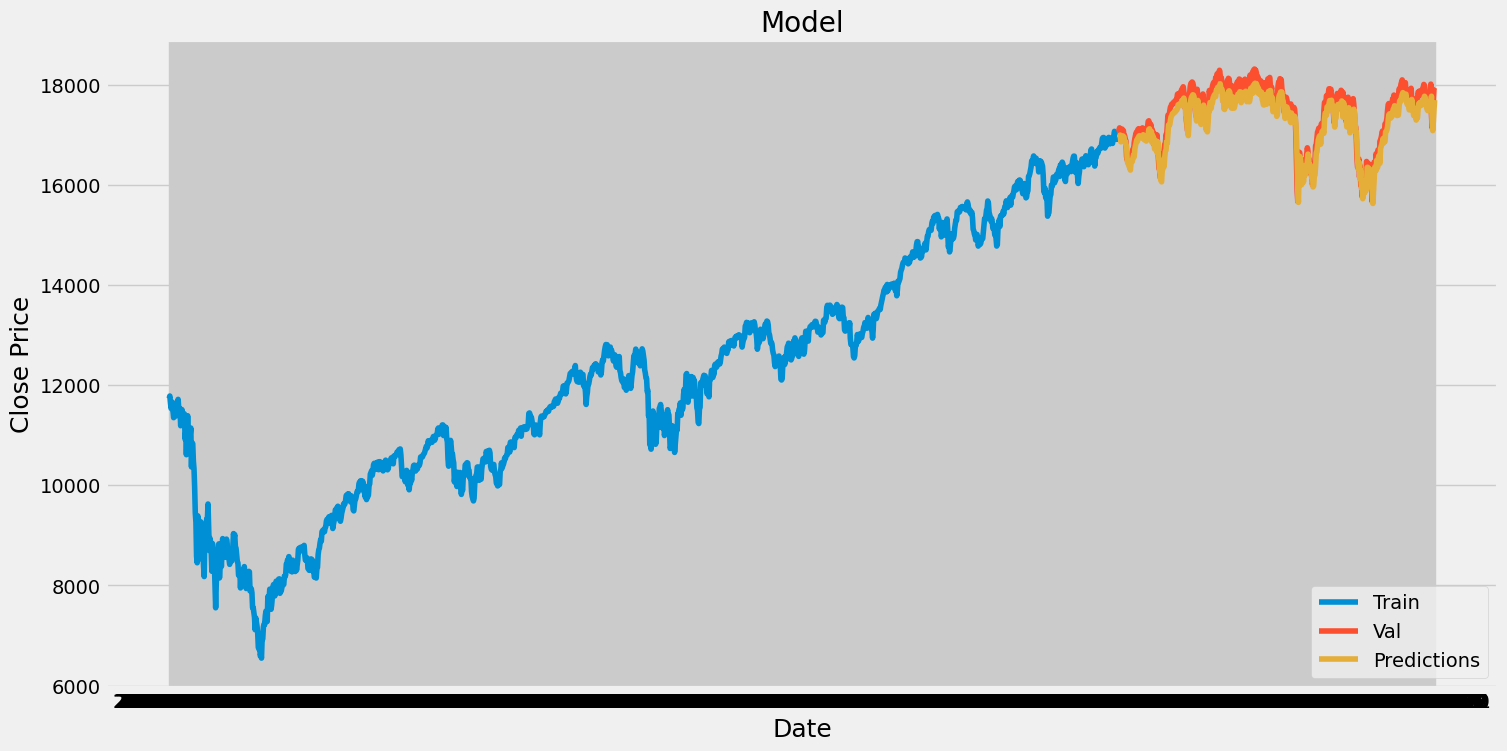

In [ ]:
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions

#Visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price',fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close','Predictions']])
plt.legend(['Train','Val','Predictions'],loc='lower right')
plt.show()


In [ ]:

valid['Predictions']

,Predictions
Date,
2014-07-15,16920.785156
2014-07-16,16927.294922
2014-07-17,16994.640625
2014-07-18,16857.396484
2014-07-21,16964.113281
...,...
2016-06-27,17274.566406
2016-06-28,17082.511719
2016-06-29,17266.667969


In [ ]:
predictions_ARIMA_store

,0
Date,
2014-07-14,15932.298617
2014-07-15,15924.728208
2014-07-16,15925.109179
2014-07-17,15920.426211
2014-07-18,15937.982075
...,...
2016-06-27,17845.958640
2016-06-28,17893.875525
2016-06-29,17879.914215


In [ ]:
rmse_ARIMA

np.float64(2202.090146862148)

In [ ]:
rmse_LSTM

np.float64(166.6067027214537)

In [ ]:

ratio_lstm=rmse_ARIMA/(rmse_LSTM+rmse_ARIMA)
print(ratio_lstm)
ratio_ARIMA=rmse_LSTM/(rmse_LSTM+rmse_ARIMA)
print(ratio_ARIMA)

0.9296631382987056
0.07033686170129448


In [ ]:
final_lstm=[]

for i in valid['Predictions']:
  final_lstm.append(ratio_lstm*i)
print(len(final_lstm))


497


In [ ]:

final_arima=[]

for i in predictions_ARIMA_store:
  final_arima.append(ratio_ARIMA*i)
final_arima.pop()
len(final_arima)

497

In [ ]:
final_predicted_values=[]

for i in range(len(final_arima)):
  final_predicted_values.append(final_arima[i]+final_lstm[i])
final_predicted_values.reverse


<function list.reverse()>

In [ ]:
final_preds=final_predicted_values

In [ ]:

#df2=df["Date"]
df2=df.iloc[::-1]
df2

,Date,Open,High,Low,Close,Volume,Adj Close
1988,2008-08-08,11432.089844,11759.959961,11388.040039,11734.320312,212830000,11734.320312
1987,2008-08-11,11729.669922,11867.110352,11675.530273,11782.349609,183190000,11782.349609
1986,2008-08-12,11781.700195,11782.349609,11601.519531,11642.469727,173590000,11642.469727
1985,2008-08-13,11632.809570,11633.780273,11453.339844,11532.959961,182550000,11532.959961
1984,2008-08-14,11532.070312,11718.280273,11450.889648,11615.929688,159790000,11615.929688
...,...,...,...,...,...,...,...
4,2016-06-27,17355.210938,17355.210938,17063.080078,17140.240234,138740000,17140.240234
3,2016-06-28,17190.509766,17409.720703,17190.509766,17409.720703,112190000,17409.720703
2,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688
1,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234


In [ ]:

df3=df2[int(len(df2)*0.75):]
#df2=df2.set_index('Date')
df3

,Date,Open,High,Low,Close,Volume,Adj Close
497,2014-07-14,16950.929688,17088.429688,16950.929688,17055.419922,60570000,17055.419922
496,2014-07-15,17055.029297,17120.339844,17006.390625,17060.679688,101730000,17060.679688
495,2014-07-16,17061.910156,17139.349609,17061.910156,17138.199219,111500000,17138.199219
494,2014-07-17,17133.449219,17151.560547,16966.189453,16976.810547,99240000,16976.810547
493,2014-07-18,16978.160156,17113.509766,16977.519531,17100.179688,112530000,17100.179688
...,...,...,...,...,...,...,...
4,2016-06-27,17355.210938,17355.210938,17063.080078,17140.240234,138740000,17140.240234
3,2016-06-28,17190.509766,17409.720703,17190.509766,17409.720703,112190000,17409.720703
2,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688
1,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234


In [ ]:
#df3.
df3.drop(df3.tail(1).index,inplace=True)
df3


/tmp/ipython-input-399-1749556824.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3.drop(df3.tail(1).index,inplace=True)


,Date,Open,High,Low,Close,Volume,Adj Close
497,2014-07-14,16950.929688,17088.429688,16950.929688,17055.419922,60570000,17055.419922
496,2014-07-15,17055.029297,17120.339844,17006.390625,17060.679688,101730000,17060.679688
495,2014-07-16,17061.910156,17139.349609,17061.910156,17138.199219,111500000,17138.199219
494,2014-07-17,17133.449219,17151.560547,16966.189453,16976.810547,99240000,16976.810547
493,2014-07-18,16978.160156,17113.509766,16977.519531,17100.179688,112530000,17100.179688
...,...,...,...,...,...,...,...
5,2016-06-24,17946.630859,17946.630859,17356.339844,17400.750000,239000000,17400.750000
4,2016-06-27,17355.210938,17355.210938,17063.080078,17140.240234,138740000,17140.240234
3,2016-06-28,17190.509766,17409.720703,17190.509766,17409.720703,112190000,17409.720703
2,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688


In [ ]:

final_predicted_values = pd.DataFrame(final_preds)
final_predicted_values=final_predicted_values.set_index(df3["Date"])
final_predicted_values["Close"]=final_predicted_values
#final_predicted_values["Date"]=list(df3["Date"])
#final_predicted_values.rename(columns={"0": "Close"})
#final_predicted_values=final_predicted_values.drop([' '],axis=1)
final_predicted_values


,0,Close
Date,,
2014-07-14,16851.258115,16851.258115
2014-07-15,16856.777526,16856.777526
2014-07-16,16919.413140,16919.413140
2014-07-17,16791.492936,16791.492936
2014-07-18,16891.938433,16891.938433
...,...,...
2016-06-24,17310.314127,17310.314127
2016-06-27,17136.210179,17136.210179
2016-06-28,17310.783780,17310.783780


In [ ]:

list(final_predicted_values.columns)

[0, 'Close']

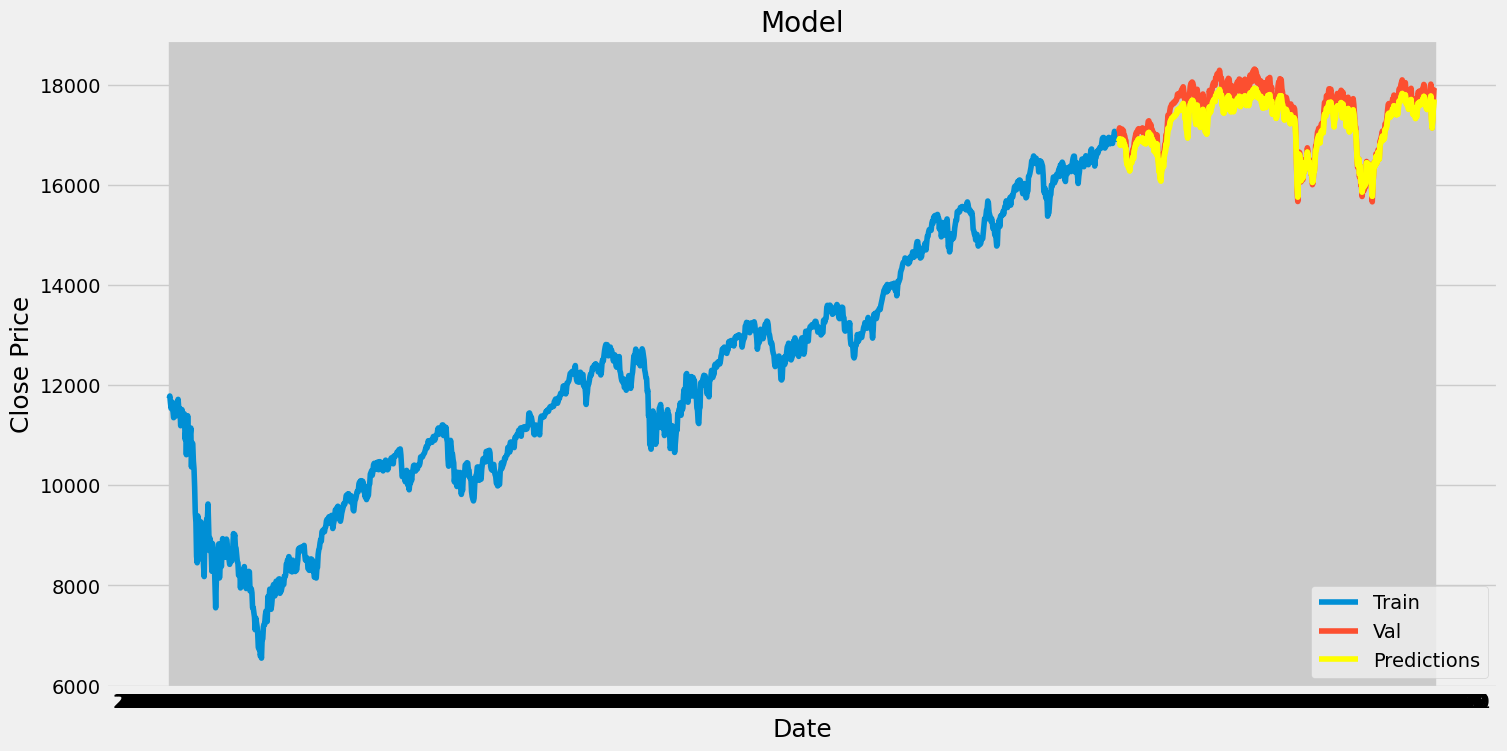

In [ ]:

plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price',fontsize=18)

#ax2 = plt.subplot(212)
#true_targets = plt.plot([:, 0, :])
#guessed_targets = plt.plot(final_predicted_values[:, 0, :], linestyle='--')
#xmin=

plt.plot(train['Close'])
plt.plot(valid['Close'])
plt.plot((final_predicted_values),'yellow')
plt.legend(['Train','Val','Predictions'],loc='lower right')
plt.show()

# **Sentiment Analysis**

In [ ]:

import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Combined_News_DJIA.csv to Combined_News_DJIA (2).csv


In [ ]:
import numpy as np
import pandas as pd
df_stock=pd.read_csv('upload_DJIA_table.csv')
df= pd.read_csv('Combined_News_DJIA.csv')
df.head()

,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top16,Top17,Top18,Top19,Top20,Top21,Top22,Top23,Top24,Top25
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,b'Georgia Invades South Ossetia - if Russia ge...,b'Al-Qaeda Faces Islamist Backlash',"b'Condoleezza Rice: ""The US would not act to p...",b'This is a busy day: The European Union has ...,"b""Georgia will withdraw 1,000 soldiers from Ir...",b'Why the Pentagon Thinks Attacking Iran is a ...,b'Caucasus in crisis: Georgia invades South Os...,b'Indian shoe manufactory - And again in a se...,b'Visitors Suffering from Mental Illnesses Ban...,"b""No Help for Mexico's Kidnapping Surge"""
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,b'Israel and the US behind the Georgian aggres...,"b'""Do not believe TV, neither Russian nor Geor...",b'Riots are still going on in Montreal (Canada...,b'China to overtake US as largest manufacturer',b'War in South Ossetia [PICS]',b'Israeli Physicians Group Condemns State Tort...,b' Russia has just beaten the United States ov...,b'Perhaps *the* question about the Georgia - R...,b'Russia is so much better at war',"b""So this is what it's come to: trading sex fo..."
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,b'U.S. troops still in Georgia (did you know t...,b'Why Russias response to Georgia was right',"b'Gorbachev accuses U.S. of making a ""serious ...","b'Russia, Georgia, and NATO: Cold War Two'",b'Remember that adorable 62-year-old who led y...,b'War in Georgia: The Israeli connection',b'All signs point to the US encouraging Georgi...,b'Christopher King argues that the US and NATO...,b'America: The New Mexico?',"b""BBC NEWS | Asia-Pacific | Extinction 'by man..."
3,2008-08-13,0,b' U.S. refuses Israel weapons to attack Iran:...,"b""When the president ordered to attack Tskhinv...",b' Israel clears troops who killed Reuters cam...,b'Britain\'s policy of being tough on drugs is...,b'Body of 14 year old found in trunk; Latest (...,b'China has moved 10 *million* quake survivors...,"b""Bush announces Operation Get All Up In Russi...",b'Russian forces sink Georgian ships ',...,b'Elephants extinct by 2020?',b'US humanitarian missions soon in Georgia - i...,"b""Georgia's DDOS came from US sources""","b'Russian convoy heads into Georgia, violating...",b'Israeli defence minister: US against strike ...,b'Gorbachev: We Had No Choice',b'Witness: Russian forces head towards Tbilisi...,b' Quarter of Russians blame U.S. for conflict...,b'Georgian president says US military will ta...,b'2006: Nobel laureate Aleksander Solzhenitsyn...
4,2008-08-14,1,b'All the experts admit that we should legalis...,b'War in South Osetia - 89 pictures made by a ...,b'Swedish wrestler Ara Abrahamian throws away ...,b'Russia exaggerated the death toll in South O...,b'Missile That Killed 9 Inside Pakistan May Ha...,"b""Rushdie Condemns Random House's Refusal to P...",b'Poland and US agree 

In [ ]:
# Combine news headlines as one column
df["combined news"]=df.loc[:,"Top1":"Top25"].astype(str).agg(" ".join,axis=1)

In [ ]:
#cleaning the text column

stop=set(stopwords.words("english"))
lemmatizer=WordNetLemmatizer()

def clean_text(text):
  text=re.sub(r"b[\"']"," ",text.lower())
  text=re.sub(r"\[.*?\]\(.*?\)","",text)
  text=re.sub(r"[^\w\s]"," ",text)
  text=re.sub(r"\s+"," ",text)
  tokens=word_tokenize(text)
  output=[lemmatizer.lemmatize(words) for words in tokens if words.isalpha() and words not in stop]
  return " ".join(output)

df["clean text"]=df["combined news"].apply(clean_text)

In [ ]:
#f['scores']=df['Top1'].apply(lambda review: sid.polarity_scores(review))
#df['compound']=df['scores'].apply(lambda score_dict:score_dict['compound'])
#df['comp_score']=df['compound'].apply(lambda c:'pos' if c>=0 else 'neg')
#df.head()

In [ ]:
!pip install vaderSentiment

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyse=SentimentIntensityAnalyzer()

analyse.polarity_scores(df["clean text"][1])

{'neg': 0.284, 'neu': 0.613, 'pos': 0.103, 'compound': -0.9895}

In [ ]:

def get_sentiment(text):
    return analyse.polarity_scores(str(text))

In [ ]:
def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

def getSIA(text):
    sia = SentimentIntensityAnalyzer()
    sentiment= sia.polarity_scores(text)
    return sentiment

In [ ]:
df['Subjectivity'] = df['clean text'].apply(get_subjectivity)
df['Polarity'] = df['clean text'].apply(get_polarity)

In [ ]:
#get Sentiment score for each day:

compound = []
neg = []
pos = []
neu = []

for i in range(len(df["clean text"])):
    SIA = get_sentiment(df["clean text"].iloc[i])
    compound.append(SIA["compound"])
    neg.append(SIA["neg"])
    pos.append(SIA["pos"])
    neu.append(SIA["neu"])

df["compound"] = compound
df["neg"] = neg
df["pos"] = pos
df["neu"] = neu

In [ ]:
df["compound"]=compound
df["neg"]=neg
df["pos"]=pos
df["neu"]=neu

In [ ]:
df['comp_score']=df['compound'].apply(lambda c:'pos' if c>=0 else 'neg')
df.head()

,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top25,combined news,clean text,Subjectivity,Polarity,compound,neg,pos,neu,comp_score
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,"b""No Help for Mexico's Kidnapping Surge""","b""Georgia 'downs two Russian warplanes' as cou...",georgia down two russian warplane country move...,0.254960,-0.047536,-0.9971,0.287,0.067,0.646,neg
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,"b""So this is what it's come to: trading sex fo...",b'Why wont America and Nato help us? If they w...,wont america nato help u wont help u help iraq...,0.346443,0.113565,-0.9895,0.284,0.103,0.613,neg
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,"b""BBC NEWS | Asia-Pacific | Extinction 'by man...",b'Remember that adorable 9-year-old who sang a...,remember adorable year old sang opening ceremo...,0.506694,-0.026211,-0.9942,0.259,0.091,0.650,neg
3,2008-08-13,0,b' U.S. refuses Israel weapons to attack Iran:...,"b""When the president ordered to attack Tskhinv...",b' Israel clears troops who killed Reuters cam...,b'Britain\'s policy of being tough on drugs is...,b'Body of 14 year old found in trunk; Latest (...,b'China has moved 10 *million* quake survivors...,"b""Bush announces Operation Get All Up In Russi...",b'Russian forces sink Georgian ships ',...,b'2006: Nobel laureate Aleksander Solzhenitsyn...,b' U.S. refuses Israel weapons to attack Iran:...,u refuse israel weapon attack iran report pres...,0.335034,0.014531,-0.9712,0.199,0.104,0.697,neg
4,2008-08-14,1,b'All the experts admit that we should legalis...,b'War in South Osetia - 89 pictures made by a ...,b'Swedish wrestler Ara Abrahamian throws away ...,b'Russia exaggerated the death toll in South O...,b'Missile That Killed 9 Inside Pakistan May Ha...,"b""Rushdie Condemns Random House's Refusal to P...",b'Poland and US agree to missle defense deal. ...,"b'Will the Russians conquer Tblisi? Bet on it,...",...,b'Philippines : Peace Advocate say Muslims nee...,b'All the experts admit that we should legalis...,expert admit legalise drug war south osetia pi...,0.344004,0.037480,-0.9855,0.249,0.131,0.620,neg


In [ ]:
#df_stock["Date"]=df_stock["Date"][ ::-1]
df_stock=df_stock.iloc[::-1]
df_stock

,Date,Open,High,Low,Close,Volume,Adj Close
1988,2008-08-08,11432.089844,11759.959961,11388.040039,11734.320312,212830000,11734.320312
1987,2008-08-11,11729.669922,11867.110352,11675.530273,11782.349609,183190000,11782.349609
1986,2008-08-12,11781.700195,11782.349609,11601.519531,11642.469727,173590000,11642.469727
1985,2008-08-13,11632.809570,11633.780273,11453.339844,11532.959961,182550000,11532.959961
1984,2008-08-14,11532.070312,11718.280273,11450.889648,11615.929688,159790000,11615.929688
...,...,...,...,...,...,...,...
4,2016-06-27,17355.210938,17355.210938,17063.080078,17140.240234,138740000,17140.240234
3,2016-06-28,17190.509766,17409.720703,17190.509766,17409.720703,112190000,17409.720703
2,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688
1,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234


In [ ]:
final_predicted_values["Date"]= final_predicted_values.index

In [ ]:

df_stock_new=pd.DataFrame({"Date":final_predicted_values["Date"],'Close':final_predicted_values["Close"]})
df_stock_new["Close"]=df_stock_new["Close"].rolling(5,min_periods=1).mean()
#df_stock_new = df_stock_new.iloc[4:]
#df_stock_new.drop(df.tail(1).index,inplace=True)#dropping last row to match final_predictions dimensions
df_stock_new

,Date,Close
Date,,
2014-07-14,2014-07-14,16851.258115
2014-07-15,2014-07-15,16854.017820
2014-07-16,2014-07-16,16875.816260
2014-07-17,2014-07-17,16854.735429
2014-07-18,2014-07-18,16862.176030
...,...,...
2016-06-24,2016-06-24,17586.148727
2016-06-27,2016-06-27,17489.441562
2016-06-28,2016-06-28,17425.482079


In [ ]:

#Standard Deviation
df_stock_new["std"]=df_stock_new["Close"].rolling(5,min_periods=1).std()
df_stock_new['std']=df_stock_new['std'].fillna(method="bfill")
df_stock_new

/tmp/ipython-input-421-183248754.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_stock_new['std']=df_stock_new['std'].fillna(method="bfill")


,Date,Close,std
Date,,,
2014-07-14,2014-07-14,16851.258115,1.951406
2014-07-15,2014-07-15,16854.017820,1.951406
2014-07-16,2014-07-16,16875.816260,13.452945
2014-07-17,2014-07-17,16854.735429,11.339086
2014-07-18,2014-07-18,16862.176030,9.924904
...,...,...,...
2016-06-24,2016-06-24,17586.148727,28.960266
2016-06-27,2016-06-27,17489.441562,51.130083
2016-06-28,2016-06-28,17425.482079,83.458455


In [ ]:

df_new=pd.DataFrame({"date":df["Date"].tail(502),'compound':df["compound"].tail(502)})
#new_compound=np.array(df_new['compound'].tail(502))
#replace 497 with len(predicted_final_values)
df_new = df_new.iloc[4:]
df_new.drop(df_new.tail(1).index,inplace=True)#dropping last row to match
df_new

,date,compound
1491,2014-07-14,-0.9825
1492,2014-07-15,-0.9867
1493,2014-07-16,-0.9967
1494,2014-07-17,-0.9948
1495,2014-07-18,-0.9963
...,...,...
1983,2016-06-24,-0.5106
1984,2016-06-27,-0.9831
1985,2016-06-28,-0.9450
1986,2016-06-29,-0.9925


In [ ]:
combined_mu=np.array(df_new["compound"])*np.array(df_stock_new["std"])
#len(combined_mu)
combined_mu=list(combined_mu)

In [ ]:

final_pred=[]
for i in range(len(combined_mu)):
   final_pred.append(final_preds[i]+ combined_mu[i])

In [ ]:
final_predicted_df = pd.DataFrame(final_pred)
final_predicted_df=final_predicted_df.set_index(df3["Date"])
final_predicted_df

,0
Date,
2014-07-14,16849.340859
2014-07-15,16854.852073
2014-07-16,16906.004589
2014-07-17,16780.212813
2014-07-18,16882.050251
...,...
2016-06-24,17295.527015
2016-06-27,17085.944194
2016-06-28,17231.915540


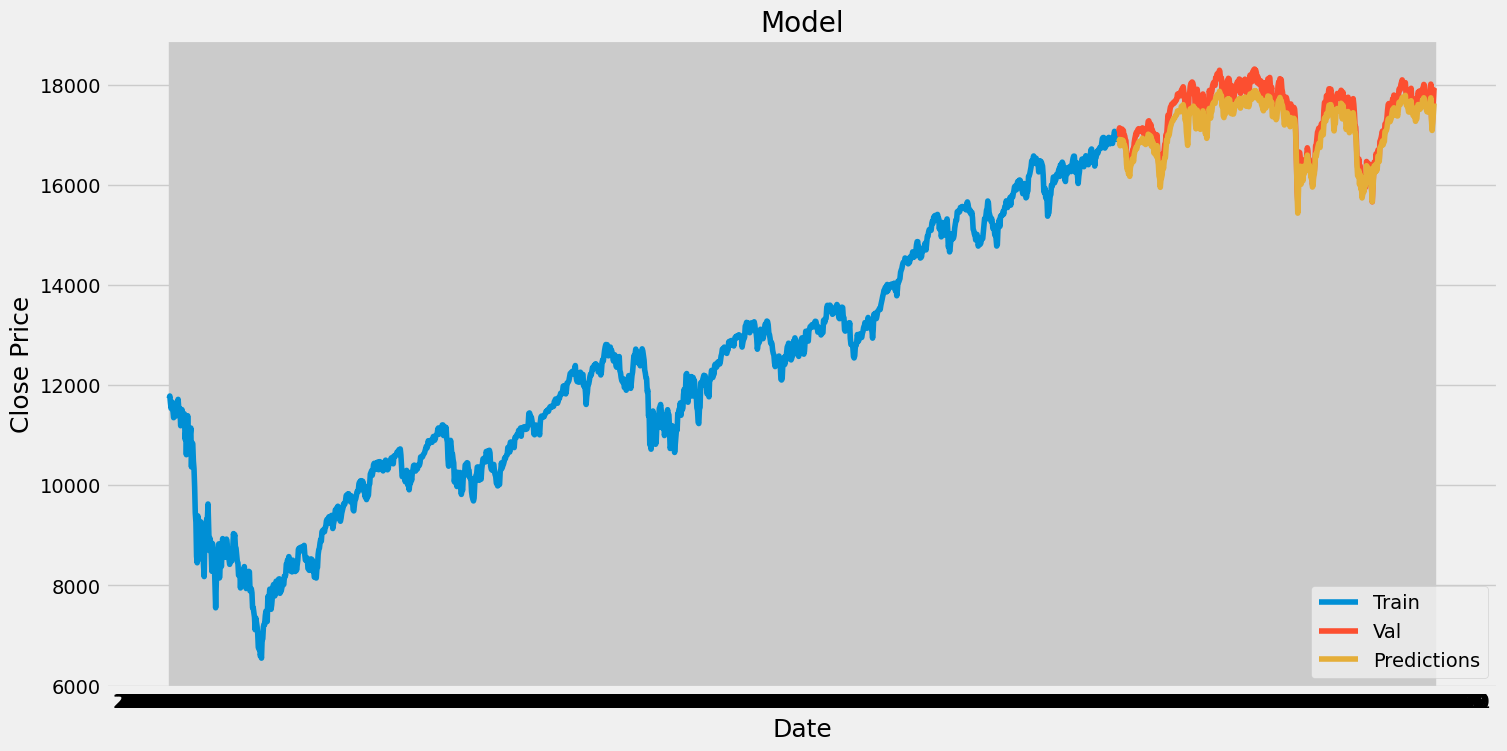

In [ ]:

plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price',fontsize=18)

#ax2 = plt.subplot(212)
#true_targets = plt.plot([:, 0, :])
#guessed_targets = plt.plot(final_predicted_values[:, 0, :], linestyle='--')
#xmin=

plt.plot(train['Close'])
plt.plot(valid['Close'])
plt.plot((final_predicted_df))
plt.legend(['Train','Val','Predictions'],loc='lower right')
plt.show()

In [ ]:
# align true vs predicted
y_true = valid['Close'].values
y_pred = final_predicted_df.iloc[:,0].values  # first column of DataFrame

In [ ]:
# check lengths match
print(f"Length of y_true: {len(y_true)}")
print(f"Length of y_pred: {len(y_pred)}")


Length of y_true: 497
Length of y_pred: 497


In [ ]:

# calculate RMSE
rmse = np.sqrt(np.mean((y_pred - y_true)**2))
print(f"RMSE of final hybrid model: {rmse:.4f}")

RMSE of final hybrid model: 307.7979


In [ ]:

# calculate MAPE
mape = np.mean(np.abs((y_true - y_pred)/y_true)) * 100
print(f"MAPE of final hybrid model: {mape:.2f}%")

MAPE of final hybrid model: 1.56%
